## IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import datetime as dt

## LOAD DATASET

In [2]:
data = pd.read_csv("Retail_Transaction_Dataset.csv")

In [3]:
data

,CustomerID,ProductID,Quantity,Price,TransactionDate,PaymentMethod,StoreLocation,ProductCategory,DiscountApplied(%),TotalAmount
0,109318,C,7,80.079844,12/26/2023 12:32,Cash,"176 Andrew Cliffs\nBaileyfort, HI 93354",Books,18.677100,455.862764
1,993229,C,4,75.195229,8/5/2023 0:00,Cash,"11635 William Well Suite 809\nEast Kara, MT 19483",Home Decor,14.121365,258.306546
2,579675,A,8,31.528816,3/11/2024 18:51,Cash,"910 Mendez Ville Suite 909\nPort Lauraland, MO...",Books,15.943701,212.015651
3,799826,D,5,98.880218,10/27/2023 22:00,PayPal,"87522 Sharon Corners Suite 500\nLake Tammy, MO...",Books,6.686337,461.343769
4,121413,A,7,93.188512,12/22/2023 11:38,Cash,"0070 Michelle Island Suite 143\nHoland, VA 80142",Electronics,4.030096,626.030484
...,...,...,...,...,...,...,...,...,...,...
99995,726461,A,2,56.078258,7/17/2023 16:59,Credit Card,"3632 Darren Station Apt. 553\nEricaborough, RI...",Clothing,18.345145,91.581240
99996,328056,A,6,88.516406,5/30/2023 9:04,Credit Card,"821 Taylor Shoals\nEvansville, IL 70845",Electronics,3.995541,509.878179
99997,887304,B,4,72.385564,8/25/2023 7:59,Credit Card,"50653 Kara Lakes\nStephanieborough, RI 94492",Clothing,17.423979,239.092472
99998,326401,C,5,66.542239,2/5/2024 19:45,PayPal,"18756 Mcfarland Way Suite 866\nBarnettside, PR...",Electronics,14.345018,284.983717


In [4]:
data.shape

(100000, 10)

In [5]:
data.columns

Index(['CustomerID', 'ProductID', 'Quantity', 'Price', 'TransactionDate',
       'PaymentMethod', 'StoreLocation', 'ProductCategory',
       'DiscountApplied(%)', 'TotalAmount'],
      dtype='object')

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   CustomerID          100000 non-null  int64  
 1   ProductID           100000 non-null  object 
 2   Quantity            100000 non-null  int64  
 3   Price               100000 non-null  float64
 4   TransactionDate     100000 non-null  object 
 5   PaymentMethod       100000 non-null  object 
 6   StoreLocation       100000 non-null  object 
 7   ProductCategory     100000 non-null  object 
 8   DiscountApplied(%)  100000 non-null  float64
 9   TotalAmount         100000 non-null  float64
dtypes: float64(3), int64(2), object(5)
memory usage: 7.6+ MB


In [7]:
data.describe()

,CustomerID,Quantity,Price,DiscountApplied(%),TotalAmount
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,500463.982180,5.009290,55.067344,10.020155,248.334955
std,288460.917524,2.579808,25.971567,5.779534,184.554792
min,14.000000,1.000000,10.000430,0.000046,8.274825
25%,250693.750000,3.000000,32.549474,5.001013,95.163418
50%,499679.000000,5.000000,55.116789,10.030353,200.368393
75%,751104.750000,7.000000,77.456763,15.018367,362.009980
max,999997.000000,9.000000,99.999284,19.999585,896.141242


## EDA

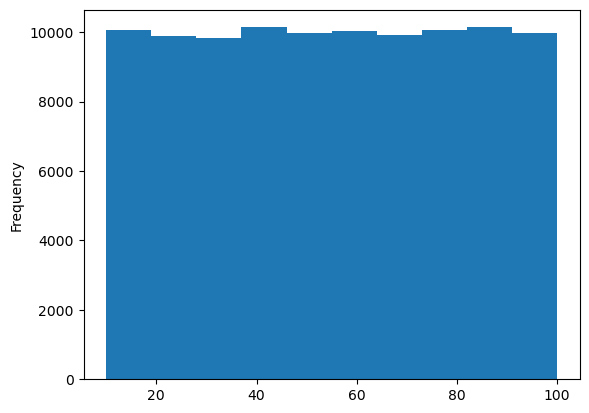

In [8]:
data['Price'].plot(kind = 'hist');

<Axes: ylabel='Frequency'>

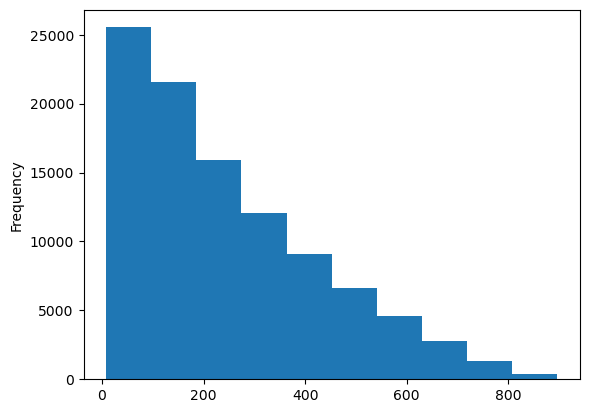

In [9]:
data['TotalAmount'].plot(kind='hist')

## FEATURE ENGINEERING

In [10]:
data.isna().sum()

CustomerID            0
ProductID             0
Quantity              0
Price                 0
TransactionDate       0
PaymentMethod         0
StoreLocation         0
ProductCategory       0
DiscountApplied(%)    0
TotalAmount           0
dtype: int64

In [11]:
data.duplicated().sum()

np.int64(0)

In [12]:
data['TransactionDate'] = pd.to_datetime(data['TransactionDate'])

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   CustomerID          100000 non-null  int64         
 1   ProductID           100000 non-null  object        
 2   Quantity            100000 non-null  int64         
 3   Price               100000 non-null  float64       
 4   TransactionDate     100000 non-null  datetime64[ns]
 5   PaymentMethod       100000 non-null  object        
 6   StoreLocation       100000 non-null  object        
 7   ProductCategory     100000 non-null  object        
 8   DiscountApplied(%)  100000 non-null  float64       
 9   TotalAmount         100000 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(2), object(4)
memory usage: 7.6+ MB


## RFM

In [14]:
snapshot_date = data['TransactionDate'].max() + dt.timedelta(days=1)

In [15]:
rfm = data.groupby('CustomerID').agg({
    "TransactionDate": lambda x: (snapshot_date-x.max()).days,
    'CustomerID':'count',
    'TotalAmount': 'sum'
})

In [16]:
rfm

,TransactionDate,CustomerID,TotalAmount
CustomerID,,,
14,267,1,256.232791
42,346,1,502.656523
49,329,1,21.399047
59,28,2,249.492696
65,316,1,548.006625
...,...,...,...
999910,199,1,12.441084
999931,238,1,105.039745
999977,301,1,71.135444


In [17]:
rfm.columns = ['Recency (Days)','Frequency','Monetary ($)']

In [18]:
rfm

,Recency (Days),Frequency,Monetary ($)
CustomerID,,,
14,267,1,256.232791
42,346,1,502.656523
49,329,1,21.399047
59,28,2,249.492696
65,316,1,548.006625
...,...,...,...
999910,199,1,12.441084
999931,238,1,105.039745
999977,301,1,71.135444


In [19]:
rfm.head()

,Recency (Days),Frequency,Monetary ($)
CustomerID,,,
14,267,1,256.232791
42,346,1,502.656523
49,329,1,21.399047
59,28,2,249.492696
65,316,1,548.006625


In [20]:
rfm.describe()

,Recency (Days),Frequency,Monetary ($)
count,95215.000000,95215.000000,95215.000000
mean,179.806470,1.050255,260.814950
std,105.263337,0.226357,197.112734
min,1.000000,1.000000,8.274825
25%,88.000000,1.000000,99.493069
50%,178.000000,1.000000,210.700964
75%,271.000000,1.000000,378.626330
max,365.000000,4.000000,2002.072661


## PREPROCESSING

In [21]:
scaler = StandardScaler()

In [22]:
rfm.columns

Index(['Recency (Days)', 'Frequency', 'Monetary ($)'], dtype='object')

In [23]:
X = rfm[rfm.columns]

In [24]:
X

,Recency (Days),Frequency,Monetary ($)
CustomerID,,,
14,267,1,256.232791
42,346,1,502.656523
49,329,1,21.399047
59,28,2,249.492696
65,316,1,548.006625
...,...,...,...
999910,199,1,12.441084
999931,238,1,105.039745
999977,301,1,71.135444


In [25]:
X_scaled = scaler.fit_transform(X)

## MODEL BUILDING

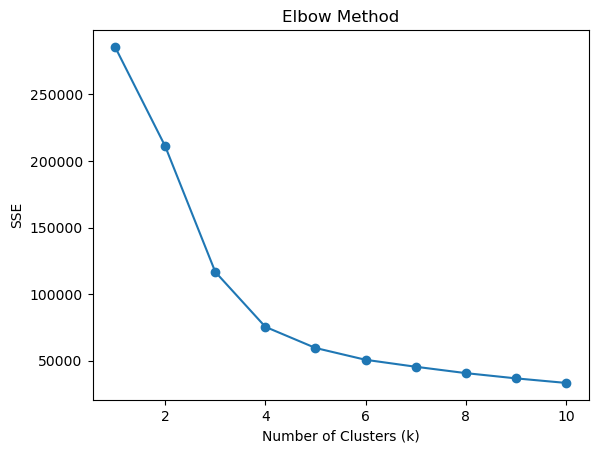

In [26]:
sse = []

for k in range(1,11):
    kmeans = KMeans(n_clusters = k, random_state = 42)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)

plt.plot(range(1,11), sse, marker = 'o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('SSE')
plt.title('Elbow Method')
plt.show()
    
    

In [27]:
kmeans = KMeans(n_clusters = 4, random_state = 500)
rfm['Cluster'] = kmeans.fit_predict(X_scaled)

print(rfm['Cluster'].value_counts())

Cluster
0    35146
2    34845
1    20603
3     4621
Name: count, dtype: int64


cluster_summary = rfm.groupby('Cluster').mean()
cluster_summary

In [28]:
rfm.groupby('Cluster').mean()

,Recency (Days),Frequency,Monetary ($)
Cluster,,,
0,88.561885,1.00000,165.450814
1,182.418628,1.00000,524.740700
2,278.288621,1.00000,168.801820
3,119.528024,2.03549,503.230718


In [29]:
cluster_labels = {0:'Low value',1: 'Lost High Value',2: 'Churned',3:'VIP'}

rfm['Segment'] = rfm['Cluster'].map(cluster_labels)

In [30]:
rfm

,Recency (Days),Frequency,Monetary ($),Cluster,Segment
CustomerID,,,,,
14,267,1,256.232791,2,Churned
42,346,1,502.656523,1,Lost High Value
49,329,1,21.399047,2,Churned
59,28,2,249.492696,3,VIP
65,316,1,548.006625,1,Lost High Value
...,...,...,...,...,...
999910,199,1,12.441084,2,Churned
999931,238,1,105.039745,2,Churned
999977,301,1,71.135444,2,Churned


## VISUALIZE THE CUSTOMERS

In [31]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X_scaled)

rfm['PCA1'] = X_pca[:,0]
rfm['PCA2'] = X_pca[:,1]

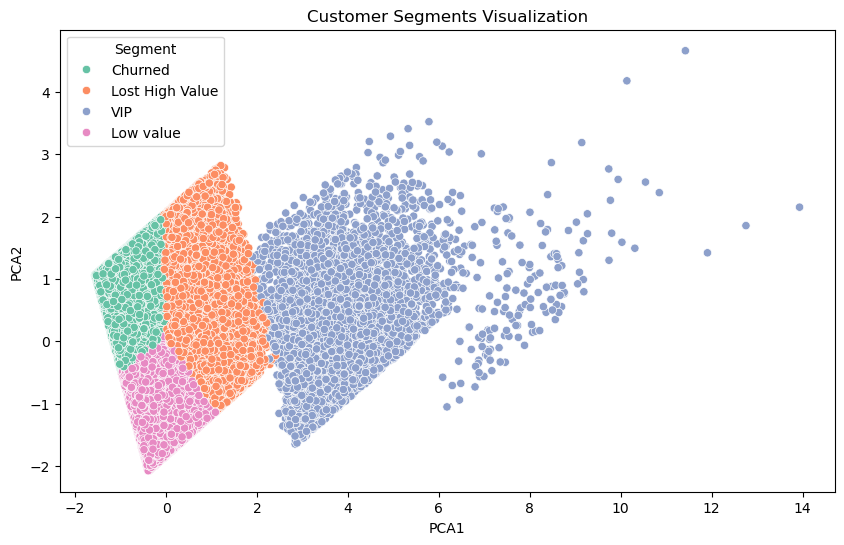

In [32]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data = rfm,
    x='PCA1',
    y='PCA2',
    hue = 'Segment',
    palette='Set2'
)

plt.title('Customer Segments Visualization')
plt.show()

## SAVE MODEL

In [37]:
joblib.dump(kmeans,'kmeans_model.pkl')

['kmeans_model.pkl']

In [38]:
joblib.dump(scaler,'Scaler.pkl')

['Scaler.pkl']